In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO

In [53]:
url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8"
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
    }

html = requests.get(url, headers=headers, timeout=30).text
table = pd.read_html(
    StringIO(html),
    match="Коефіцієнт народжуваності в регіонах України",
    thousands=".", decimal=",")[0]

print(table.to_string(index=False))

           Регіон  1950  1960  1970  1990  2000  2012 2014 2019
             Крим  23.0  20.6  16.0  13.0   7.3  12.6    —    —
        Вінницька  22.4  19.2  14.2  12.4   8.4  11.2 10.9  7.6
        Волинська  24.7  25.0  17.9  15.3  11.2  14.8 14.1 10.1
 Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2 11.1  7.1
         Донецька  27.1  21.4  14.0  10.9   6.1   9.8  8.2    —
      Житомирська  26.1  22.3  15.9  12.9   8.9  12.2 12.0  7.9
     Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1 14.6 10.4
       Запорізька  21.9  19.7  15.0  12.4   7.1  10.6 10.6  6.8
Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4 12.2  8.8
         Київська  20.4  18.9  15.6  12.3   7.3  12.2 12.1  8.0
   Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0 10.8  6.8
        Луганська  26.2  23.5  14.4  11.6   6.2   9.6  5.1    —
        Львівська  23.4  24.0  17.1  14.0   9.1  11.9 11.9  8.7
     Миколаївська  21.1  19.4  15.5  13.7   8.0  11.5 11.2  7.1
          Одеська  24.1  19.2  14.8  12.

In [54]:
# В завданні не уточнено скільки саме рядків вивести
print(table.head(1).to_string(index=False))

Регіон  1950  1960  1970  1990  2000  2012 2014 2019
  Крим  23.0  20.6  16.0  13.0   7.3  12.6    —    —


In [55]:
print(table.shape)

(28, 9)


In [56]:
table = table.replace("—", np.nan)
print(table.to_string(index=False))

           Регіон  1950  1960  1970  1990  2000  2012 2014 2019
             Крим  23.0  20.6  16.0  13.0   7.3  12.6  NaN  NaN
        Вінницька  22.4  19.2  14.2  12.4   8.4  11.2 10.9  7.6
        Волинська  24.7  25.0  17.9  15.3  11.2  14.8 14.1 10.1
 Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2 11.1  7.1
         Донецька  27.1  21.4  14.0  10.9   6.1   9.8  8.2  NaN
      Житомирська  26.1  22.3  15.9  12.9   8.9  12.2 12.0  7.9
     Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1 14.6 10.4
       Запорізька  21.9  19.7  15.0  12.4   7.1  10.6 10.6  6.8
Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4 12.2  8.8
         Київська  20.4  18.9  15.6  12.3   7.3  12.2 12.1  8.0
   Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0 10.8  6.8
        Луганська  26.2  23.5  14.4  11.6   6.2   9.6  5.1  NaN
        Львівська  23.4  24.0  17.1  14.0   9.1  11.9 11.9  8.7
     Миколаївська  21.1  19.4  15.5  13.7   8.0  11.5 11.2  7.1
          Одеська  24.1  19.2  14.8  12.

In [57]:
print(table.dtypes)

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014       object
2019       object
dtype: object


In [58]:
table = table.astype({"1950": "float64",
                      "1960": "float64",
                      "1970": "float64",
                      "2014": "float64",
                      "2019": "float64"})
print(table.dtypes)

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object


In [59]:
res = pd.DataFrame({
    "Кількість пропусків": table.isna().sum(),
    "Відсоток пропусків": table.isna().mean().mul(100).round(2)
})
print(res)

        Кількість пропусків  Відсоток пропусків
Регіон                    0                0.00
1950                      2                7.14
1960                      1                3.57
1970                      1                3.57
1990                      0                0.00
2000                      0                0.00
2012                      0                0.00
2014                      2                7.14
2019                      4               14.29


In [60]:
# Чомусь індекс [-1] не працює та видає помилку, хоча в конспекті наче писалося, що можна звертатись за індексами як у списку Python
table_new = table.drop([27])
print(table_new.to_string(index=False))

           Регіон  1950  1960  1970  1990  2000  2012  2014  2019
             Крим  23.0  20.6  16.0  13.0   7.3  12.6   NaN   NaN
        Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
        Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
 Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
         Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   NaN
      Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
     Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
       Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
         Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
   Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
        Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   NaN
        Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
     Миколаївська  21.1  19.4  15.5  13.7   8.0  11.5  11.2   7.1
          

In [61]:
table_nan = table.fillna({"1950": table["1950"].mean().round(1),
                          "1960": table["1960"].mean().round(1),
                          "1970": table["1970"].mean().round(1),
                          "2014": table["2014"].mean().round(1),
                          "2019": table["2019"].mean().round(1)})
print(table_nan.to_string(index=False))

           Регіон  1950  1960  1970  1990  2000  2012  2014  2019
             Крим  23.0  20.6  16.0  13.0   7.3  12.6  11.1   8.0
        Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
        Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
 Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
         Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   8.0
      Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
     Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
       Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
         Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
   Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
        Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   8.0
        Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
     Миколаївська  21.1  19.4  15.5  13.7   8.0  11.5  11.2   7.1
          

In [62]:
res1 = pd.DataFrame({
    "Регіон": table_nan['Регіон'],
    "2019": table_nan['2019']
})
#res1 = res1.drop([27])
res1 = res1[res1["2019"] > res1.loc[27, "2019"]]
print(res1.to_string(index=False))

           Регіон  2019
        Волинська  10.1
     Закарпатська  10.4
Івано-Франківська   8.8
        Львівська   8.7
          Одеська   8.8
       Рівненська  10.7
      Чернівецька   9.2
             Київ  11.0


In [64]:

res2 = table_nan[table_nan['2014'] == table_nan['2014'].max()]
print(res2.to_string(index=False))

    Регіон  1950  1960  1970  1990  2000  2012  2014  2019
Рівненська  26.9  26.7  19.3  15.8  11.8  15.9  14.8  10.7


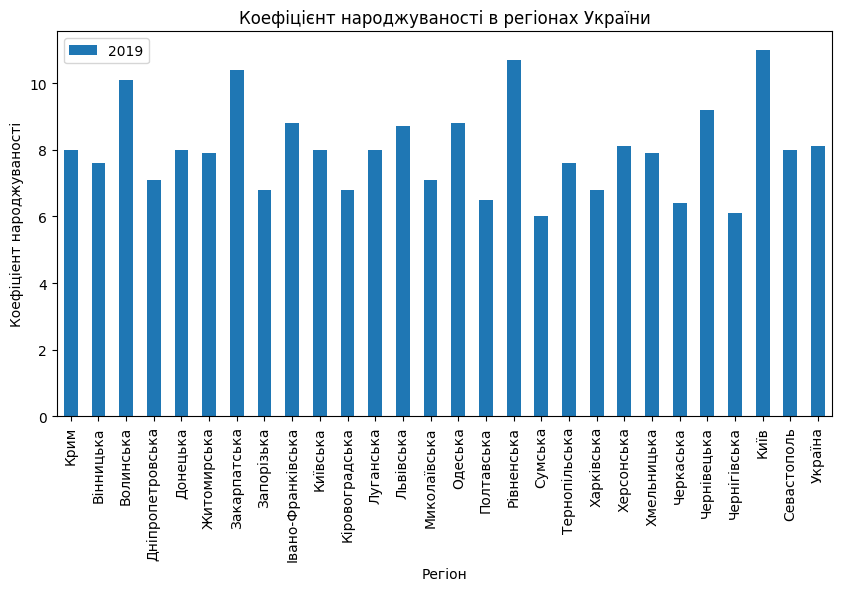

In [81]:
table_nan.plot.bar(x="Регіон", y = "2019", figsize=(10, 5))
plt.ylabel("Коефіціент народжуваності")
plt.title("Коефіцієнт народжуваності в регіонах України")
plt.show()